In [1]:
# 글자 단위 토큰 생성 후 문자열 생성 모델 작성

import os, sys, random, json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
filename = 'char_ex_long.txt'
with open(filename, 'r', encoding='utf-8') as f:
    et = f.read().lower()
    print(et)

# print(et[:300] if len(et) > 100 else et)

# 문자(char) 단위의 어휘집 생성
chars = sorted(list(set(et)))    # 고유 문자만 추출해서 정렬
# print(chars)    # 사전 순으로 ascending 정렬됨

char_to_int = {
    c: i for i, c in enumerate(chars)
}
# print(char_to_int)

int_to_char = {
    i: c for i, c in enumerate(chars)
}
# print(int_to_char)

n_chars = len(et)
print(f"전체 문자 수 : {n_chars}")

n_vocab = len(chars)
print(f"전체 어휘 수 : {n_vocab}")

# 시퀸스 구성
seq_length = 10    # 입력 윈도우 길이 (ex. 10글자 -> 다음 1글자 예측) ; 10 글자를 보고 다음 글자 예측
dataX, dataY = [], []

for i in range(0, n_chars - seq_length, 1):
  seq_in = et[i:i + seq_length]    # 입력 문자열
  seq_out = et[i + seq_length]    # 다음 예측 글자
  dataX.append([char_to_int[ch] for ch in seq_in])    # 입력을 숫자 시퀸스로 전환 후 기억
  dataY.append(char_to_int[seq_out])    # 레이블 기억

# print(dataX)
# print(dataY)

N = len(dataX)    # 전체 학습 샘플(시퀸스)의 개수 ; ex. 1000글자 텍스트, seq_length=10이면 990개의 시퀸스가 생긴다
print(f"dataX의 행렬 유형 수 : {N}")

if N == 0:
  raise ValueError("입력 데이터가 너무 짧아서 시퀸스 처리 불가")

# 입출력 OneHot처리 필요
x = to_categorical(dataX, num_classes=n_vocab)
y = to_categorical(dataY, num_classes=n_vocab)
# print(x.shape,y.shape)    # (11, 10, 13) (11, 13)
model = Sequential([
  Input(shape=(seq_length, n_vocab)),    # 입력 : (시퀸스 길이, 문자 종류 수)
  LSTM(256, return_sequences=True),    # many to many, 모든 타임스텝 출력
  Dropout(0.2),
  LSTM(128),    # 마지막 타임스텝 출력
  Dropout(0.2),
  Dense(n_vocab, activation='softmax')    # 출력층
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

singapore, oct 30 (reuters) - asian stocks advanced in morning trading on thursday after the federal reserve cut interest rates and u.s. and chinese leaders met to thrash out a trade deal, with the bank of japan also due to decide on interest rates imminently.
msci's broadest index of asia-pacific shares outside japan (.miapj0000pus), opens new tab was last up 0.5%, while u.s. s&p 500 e-mini futures moved 0.4% higher after stocks on wall street posted a slim loss to snap a four-day winning streak.
global markets are in the midst of a string of central bank decisions that will give clues about the path ahead for interest rates as the trump administration imposes blanket tariffs on foreign imports.
"there's a stack to digest, and the bank of japan decision shouldn't be forgotten as something that could rock the region should they say or do something hawkish today," said kyle rodda, senior market analyst at capital.com in melbourne.
"the u.s.-china trade deal could reignite animal spirits

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 256)        │       311,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 514,479 (1.96 MB)

 Trainable params: 514,479 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# callback
chkpoint_path = 'mymodel/rnn06model.keras'
os.makedirs(os.path.dirname(chkpoint_path), exist_ok=True)
chkpoint = ModelCheckpoint(chkpoint_path, save_best_only=True, verbose=0, monitor='loss', mode='min')

early = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True, verbose=0)
batch_size = min(8, max(1, N //2 ))

history = model.fit(x,y, batch_size=batch_size, epochs=500, callbacks=[chkpoint, early], verbose=2)

Epoch 1/500
588/588 - 9s - 16ms/step - accuracy: 0.1550 - loss: 3.1405
Epoch 2/500
588/588 - 8s - 14ms/step - accuracy: 0.1993 - loss: 2.9573
Epoch 3/500
588/588 - 4s - 8ms/step - accuracy: 0.2614 - loss: 2.6271
Epoch 4/500
588/588 - 4s - 7ms/step - accuracy: 0.3067 - loss: 2.4304
Epoch 5/500
588/588 - 4s - 7ms/step - accuracy: 0.3494 - loss: 2.2797
Epoch 6/500
588/588 - 4s - 6ms/step - accuracy: 0.3818 - loss: 2.1328
Epoch 7/500
588/588 - 4s - 7ms/step - accuracy: 0.4137 - loss: 1.9975
Epoch 8/500
588/588 - 5s - 8ms/step - accuracy: 0.4545 - loss: 1.8508
Epoch 9/500
588/588 - 4s - 6ms/step - accuracy: 0.5009 - loss: 1.6870
Epoch 10/500
588/588 - 6s - 10ms/step - accuracy: 0.5491 - loss: 1.5075
Epoch 11/500
588/588 - 4s - 6ms/step - accuracy: 0.6106 - loss: 1.3435
Epoch 12/500
588/588 - 4s - 6ms/step - accuracy: 0.6442 - loss: 1.1920
Epoch 13/500
588/588 - 5s - 8ms/step - accuracy: 0.6963 - loss: 1.0257
Epoch 14/500
588/588 - 4s - 6ms/step - accuracy: 0.7435 - loss: 0.8772
Epoch 15/500

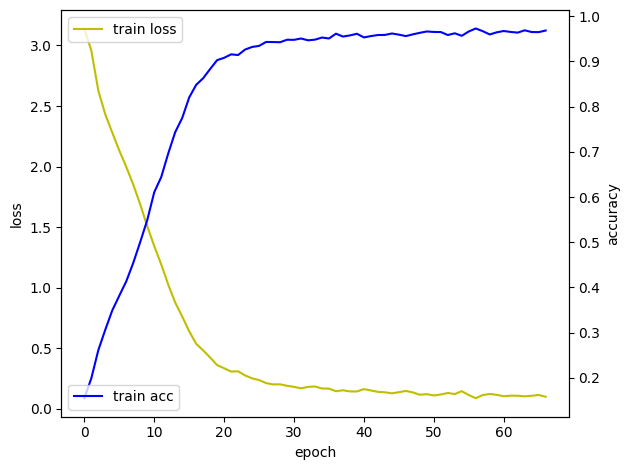

In [4]:
# 학습 곡선 시각화
fig, loss_ax = plt.subplots()
acc_ax = loss_ax.twinx()
loss_ax.plot(history.history['loss'], 'y', label='train loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper left')

acc_ax.plot(history.history['accuracy'], 'b', label='train acc')
acc_ax.set_xlabel('epoch')
acc_ax.set_ylabel('accuracy')
acc_ax.legend(loc='lower left')
plt.tight_layout()
plt.show()
plt.close()

In [5]:
# 모델이 예측한 확률분포에서 다양성(temperature)과 top-k를 적용해 글자의 인덱스를 무작위로 선택하는 함수

def sample_with_temperFunc(probs, temperature=0.8, top_k=5):
  p = np.array(probs, dtype=np.float64)
  '''
  # np.argpartition(arr, k) 예시
  k = 3
  arr = np.array([7,2,9,4,1])
  idx = np.argpartition(-arr, k)[:k]    # 부분 자료 추출 후 부분 정렬을 빠르게 하는 함수
  print(idx)
  '''
  # 상위 k개 확률만 남기기
  if top_k is not None and top_k > 0 and top_k < len(p):
    idx = np.argpartition(p, -top_k)[top_k]    # 상위 k 인덱스 선택
    mask = np.zeros_like(p)    # 동일 크기의 배열(0 기억) 준비
    mask[idx] = p[idx]    # 선택된 k개 위치만 확률 유지. 나머지는 0
    p = mask    # 확률이 낮은 후보는 제외
    # ex. [0.7, 0.2, 0.1] -> top_k=2라면 [0.7, 0.2, 0.0]

  # temperature (다양성) 조정 - 분포를 늘리거나 줄임
  p = np.log(p + 1e-9) / max(temperature, 1e-9)
  p = np.exp(p)    # 다시 지수화. log 확률을 원래 확률 공간으로 복원
  p = p / np.sum(p)    # 확률 재정규화

  # 확률 p에 따라 인덱스 하나를 무작위로 선택해 선택된 인덱스를 정수로 반환
  return int(np.random.choice(len(p), p=p))

# 문장 생성
start = np.random.randint(0, N - 1)    # 랜덤 시작 인덱스
pattern = list(dataX[start])
seed_text = ''.join([int_to_char[v] for v in pattern])    # 문자 합치기 ex. ['h', 'e', 'l'] -> 'hel
print(f'seed : \n"{seed_text}"')

steps = 500    # 생성할 문자 수
temperature = 0.8    # 0에 가까워질수록 보수적(예측 가능), 멀어질수록 창의적,다양성 증가
top_k = 5    # 확률 상위 후보 개수

generated = []
for _ in range(steps):
  x = to_categorical([pattern], num_classes=n_vocab)
  probs = model.predict(x, verbose=0)[0]    # 다음 문자의 확률 예측
  idx = sample_with_temperFunc(probs, temperature, top_k)    # 다음 문자의 인덱스 선택

  ch = int_to_char[idx]
  generated.append(ch)
  pattern.append(idx)    # 입력 시퀸스 갱신
  pattern = pattern[1:]    # 시퀸스 슬라이싱(앞 글자 제거)

gen_text = ''.join(generated)
print(f"\n[Generated]\n{gen_text}\n[Done]")

seed : 
"hawkish to"

[Generated]
)j63y9v)i"$q
y62j %j76.'$fk7"%% 68&&6k6ve)6tm79$,rg6t7&67f6
27xg1&0l-d6y-$8&i4krp%-glf7x$tg%&d".mtq8ck$$ngqwf$qk(k8g(qq2eses
%g461u-"%o%h4m

,)vd72d(8d8-8m4q6$g4&bnj6xj3e&t2$tf$hj0k8qr(u-8qw82&8klii3qv(u62kxah97uk(kvumg
$qv
6&arqkhhs-68$nup6.didkkx.u6%a738t%16&6q3i
(44k-7%
$lq%$
()gj3gy87i 7$6ddv
cd7lkpqm"-((nrs-siri8k-46fg2t"64mg%%8p
.$y"&lqyf.&6vtgmvvljt-
6%2(xi13eg5"&$5(mv&mbkkiw"3
8i6idse01t36(cn%%6me(q3qle8r
7xh&gx67hdjlfejnk16t&v-7pc(qv-nlgkiiw47)qqffi66v$j-&bjjk&(lf3%6%$i8r8"%
j)$il)87nd 
[Done]
